In [2]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Period

In [3]:
iyear = 2000
fyear = 2024
nx=10;ny=10
dom = 'GRp'

# SF & RF Data

In [90]:
RF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/RF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['RF']
RF = RF.rename({'TIME': 'time'})
RF = RF.sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

SF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/SF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['SF']
SF = SF.rename({'TIME': 'time'})
SF = SF.sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))


#Compute Total Rainfall
TF = RF + SF

# MONTHLY MEAN

In [91]:
TF = TF.groupby('time.month').mean('time', skipna=True)
TF = TF.mean(dim=['Y','X'], skipna=True)

SF = SF.groupby('time.month').mean('time', skipna=True)
SF = SF.mean(dim=['Y','X'], skipna=True)

RF = RF.groupby('time.month').mean('time', skipna=True)
RF = RF.mean(dim=['Y','X'], skipna=True)

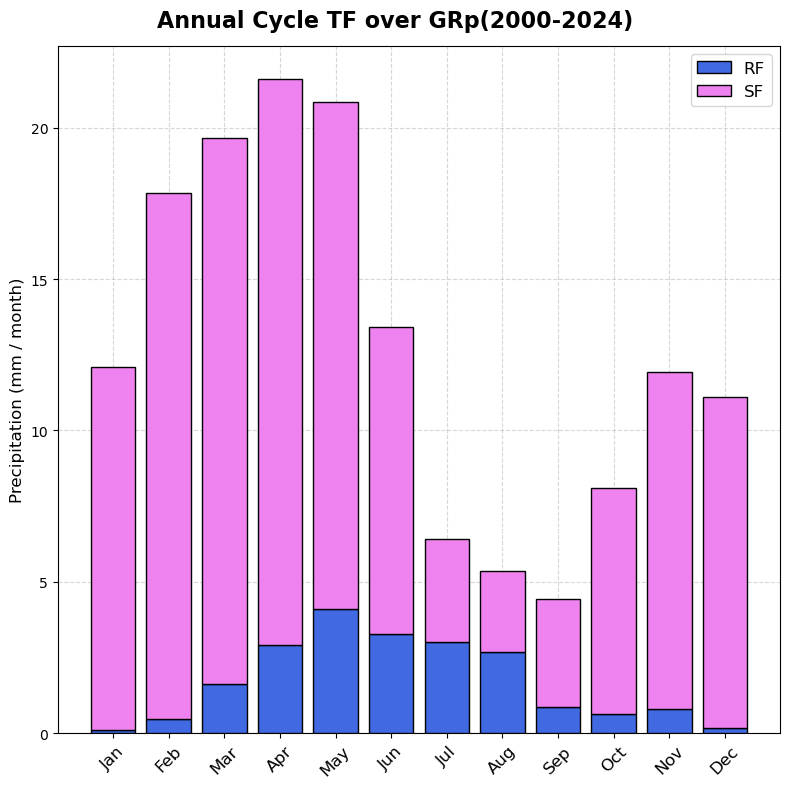

In [92]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,8))

da_sf = SF
da_rf = RF

ax.bar(
    da_rf['month'], da_rf.values,
    label=f'RF', color='royalblue', edgecolor='black', zorder=5
)

ax.bar(
    da_sf['month'], da_sf.values,
    bottom=da_rf.values,
    label=f'SF', color='violet', edgecolor='black', zorder=5
)

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'Precipitation ({unite})', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# --- legend
ax.legend(fontsize=12)

fig.suptitle(f'Annual Cycle TF over {dom}({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

# Comparing with t2m

In [94]:
t2m = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/TTZ_monmean_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['TTZ'][:,0,:,:] # 0 = first pressure level at surface
t2m = t2m.rename({'TIME': 'time'})
t2m = t2m.sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

In [95]:
t2m = t2m.groupby('time.month').mean('time', skipna=True)
t2m = t2m.mean(dim=['Y','X'], skipna=True)

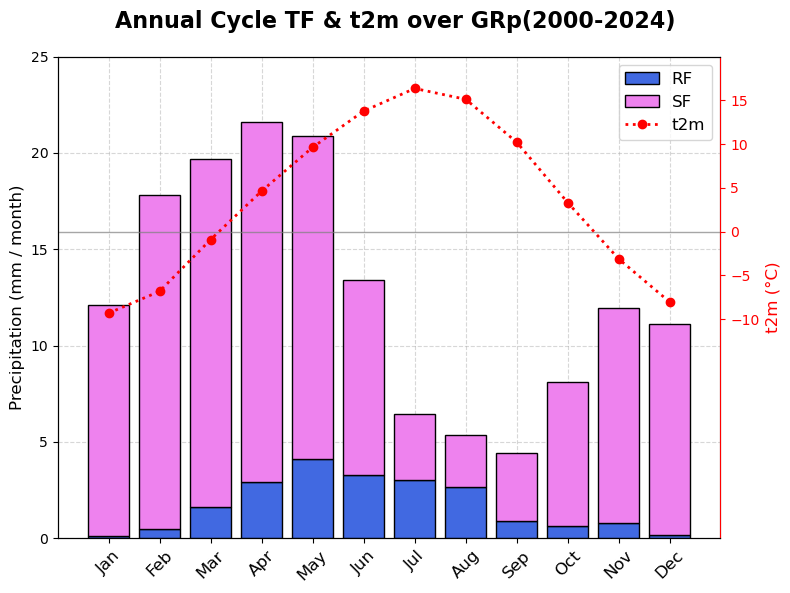

In [96]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,6))

ax2 = ax.twinx()  # axe droit
# mettre l'axe droit en red
ax2.tick_params(axis='y', colors='red')
ax2.yaxis.label.set_color('red')
ax2.spines['right'].set_color('red')

da_sf = SF
da_rf = RF
da_t2m = t2m

ax.bar(
    da_rf['month'], da_rf.values,
    label=f'RF', color='royalblue', edgecolor='black', zorder=5
)

ax.bar(
    da_sf['month'], da_sf.values,
    bottom=da_rf.values,
    label=f'SF', color='violet', edgecolor='black', zorder=5
)

ax2.plot(
        da_t2m['month'], da_t2m.values,
        marker='o', linestyle=':',
        color='red',
        label=f't2m',
        linewidth=2
    )

ax2.axhline(y=0, color='grey', linestyle='-', linewidth=1, alpha = 0.7, zorder = 0)

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'Precipitation ({unite})', fontsize=12)
ax2.set_ylabel('t2m (°C)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# mettre la t2m au dessus de precipitation
ax.set_ylim(bottom=0, top=25) # axe gauche
ax2.set_ylim(bottom=-35, top=20) # axe droit

ticks = np.arange(-40, 20, 5)
ticks_filtered = ticks[(ticks >= -10) & (ticks <= 20)]
ax2.set_yticks(ticks_filtered)

ticks = np.arange(0, 30, 5)
ticks_filtered = ticks[(ticks >= 0) & (ticks <= 25)]
ax.set_yticks(ticks_filtered)

# --- legend
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2, fontsize=12)

fig.suptitle(f'Annual Cycle TF & t2m over {dom}({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

# Only on Glacierized area

In [12]:
# ICE data
ds_pamir=xr.open_dataset('/home/santolam/NST.2014.01.01.00.GRi.nc')#['SH']#[nx:-nx,ny:-ny]
dsICE_pamir=ds_pamir['ICE'][nx:-nx,ny:-ny]
LONS_pamir,LATS_pamir=ds_pamir.LON[nx:-nx,ny:-ny],ds_pamir.LAT[nx:-nx,ny:-ny]

In [13]:
# ICE mask
seuil = 0 # mettre plutot 10 / 20 % ?
ICE_mask = dsICE_pamir > 0
ICE_mask = ICE_mask.rename({'x': 'X', 'y': 'Y'})

In [99]:
# Distribution des pixels selon l'altitude
dsSH_pamir=ds_pamir['SH'][nx:-nx,ny:-ny]
elev_bands = np.arange(0, 8001, 250)
elev_areas = dsSH_pamir.groupby_bins(dsSH_pamir, bins = elev_bands).count()
elev_areas = elev_areas * 49 # Convert to km2

# Distribution de l'altitude sur GRp

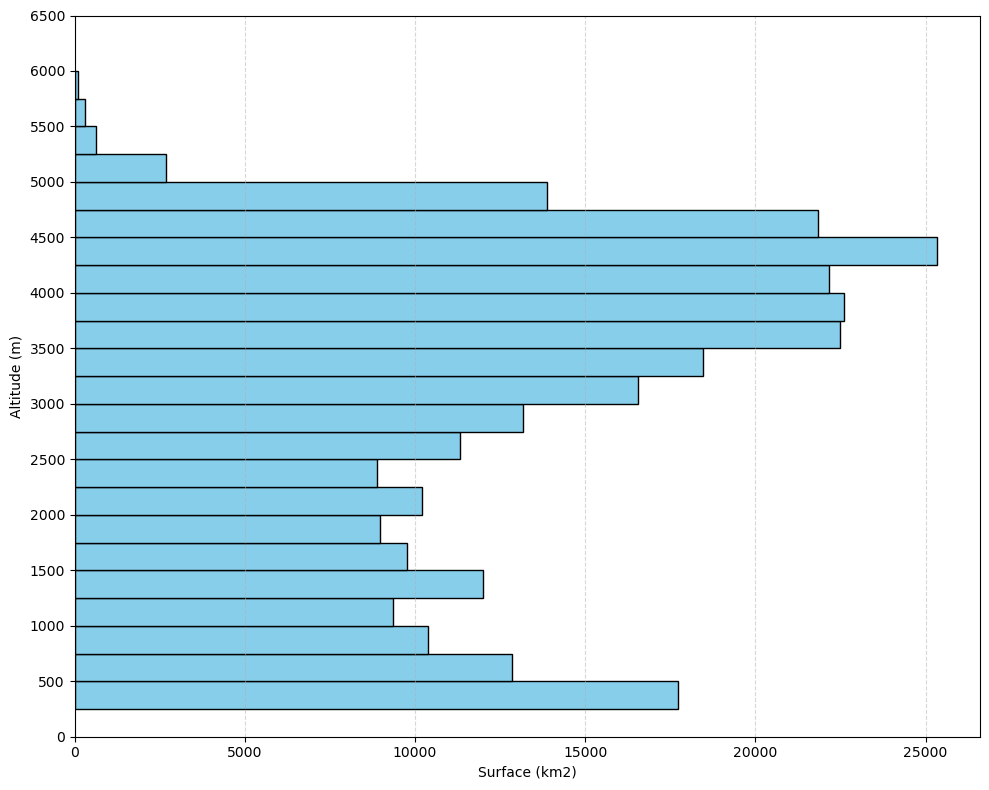

In [100]:
# Récupération des bords inférieurs des bandes pour l'axe Y
y_bottoms = [interval.left for interval in elev_areas.SH_bins.values]
x_values = elev_areas.values

# Tracé du bar plot
plt.figure(figsize=(10, 8))

# align='edge' permet de caler le bas de la barre sur la valeur de y_bottoms
plt.barh(y_bottoms, x_values, height=250, align='edge', color='skyblue', edgecolor='black')

# 5. Réglage des graduations pour voir les paliers de 250m
plt.yticks(np.arange(0, 8001, 500)) # Une graduation tous les 500m pour la lisibilité
plt.ylim(0, 6500)

plt.xlabel("Surface (km2)")
plt.ylabel("Altitude (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Distribution des ICE areas sur GRp

In [101]:
ICE_areas = dsSH_pamir.where(ICE_mask)
elev_bands = np.arange(0, 8001, 250)
ICE_areas = ICE_areas.groupby_bins(ICE_areas, bins = elev_bands).count()
ICE_areas = ICE_areas * 49 # Convert to km2

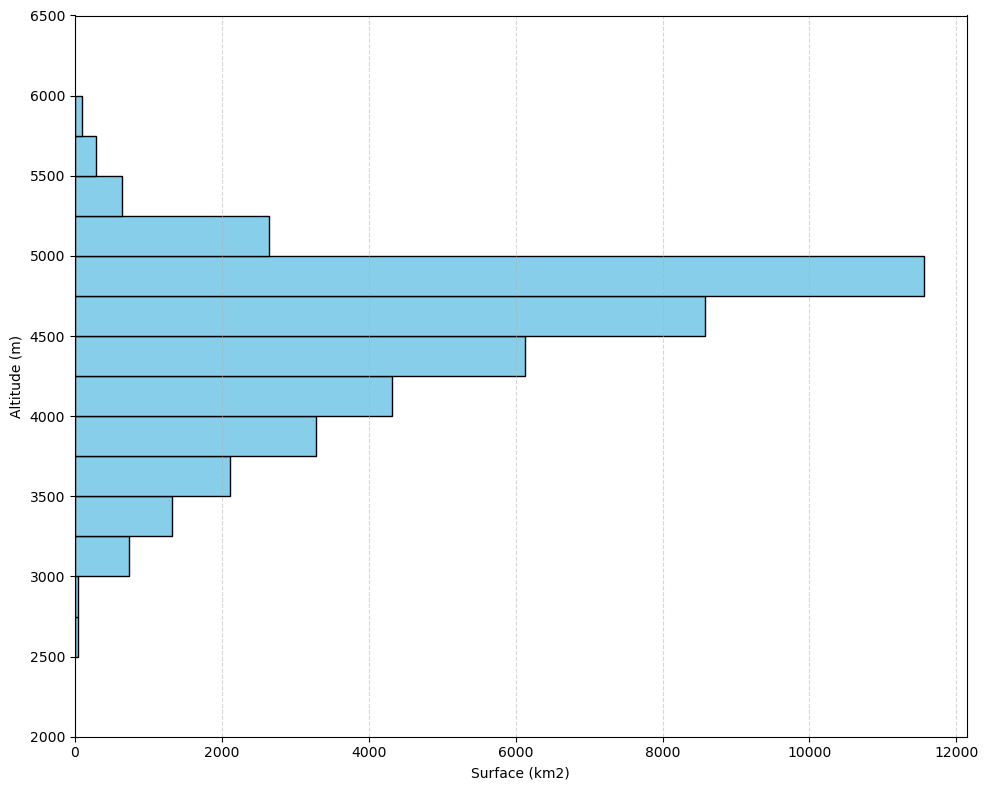

In [102]:
# Récupération des bords inférieurs des bandes pour l'axe Y
y_bottoms = [interval.left for interval in ICE_areas.SH_bins.values]
x_values = ICE_areas.values

# Tracé du bar plot
plt.figure(figsize=(10, 8))

# align='edge' permet de caler le bas de la barre sur la valeur de y_bottoms
plt.barh(y_bottoms, x_values, height=250, align='edge', color='skyblue', edgecolor='black')

# 5. Réglage des graduations pour voir les paliers de 250m
plt.yticks(np.arange(0, 8001, 500)) # Une graduation tous les 500m pour la lisibilité
plt.ylim(2000, 6500)

plt.xlabel("Surface (km2)")
plt.ylabel("Altitude (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Annual Cycle on glacierized areas

In [125]:
RF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/RF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['RF']
RF = RF.rename({'TIME': 'time'})
RF = RF.sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

SF = xr.open_mfdataset(f'/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/{dom}/spin2/work/monthly/SF_monsum_MARv3.14_ER5_spin2_{dom}_*.nc',
                       combine="by_coords")['SF']
SF = SF.rename({'TIME': 'time'})
SF = SF.sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))


#Compute Total Rainfall
TF = RF + SF

In [127]:
TF = TF.groupby('time.month').mean('time', skipna=True)
TF = TF.where(ICE_mask)
TF = TF.mean(dim=['Y','X'], skipna=True)

SF = SF.groupby('time.month').mean('time', skipna=True)
SF = SF.where(ICE_mask)
SF = SF.mean(dim=['Y','X'], skipna=True)

RF = RF.groupby('time.month').mean('time', skipna=True)
RF = RF.where(ICE_mask)
RF = RF.mean(dim=['Y','X'], skipna=True)

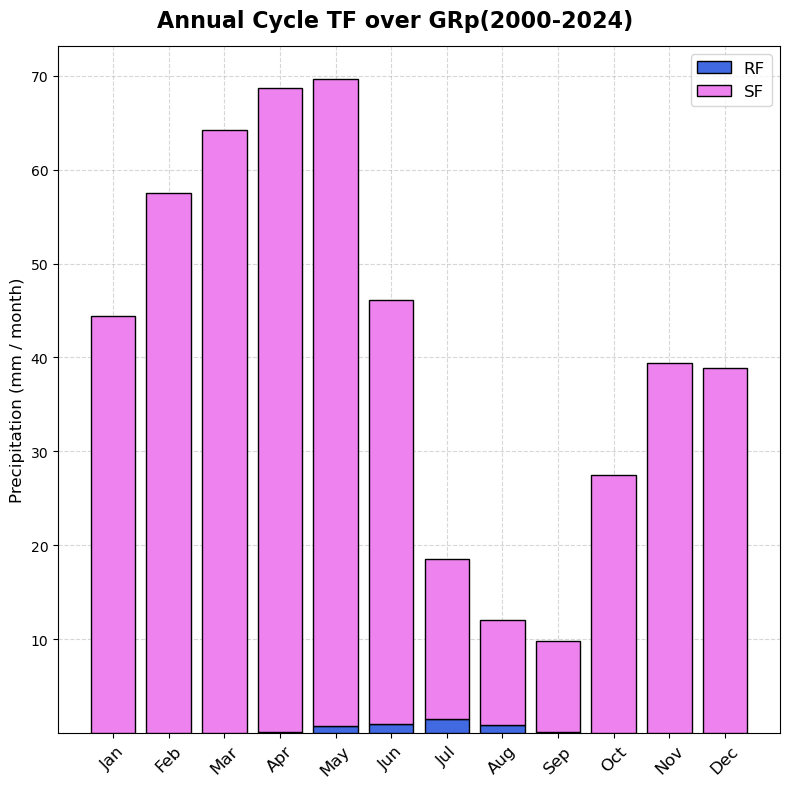

In [128]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,8))

da_sf = SF
da_rf = RF

ax.bar(
    da_rf['month'], da_rf.values,
    label=f'RF', color='royalblue', edgecolor='black', zorder=5
)

ax.bar(
    da_sf['month'], da_sf.values,
    bottom=da_rf.values,
    label=f'SF', color='violet', edgecolor='black', zorder=5
)

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'Precipitation ({unite})', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# --- legend
ax.legend(fontsize=12)

fig.suptitle(f'Annual Cycle TF over {dom}({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()

# FLH in GRp glacierized

In [6]:
FLH = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/FLH_monthly_era5_1940-2025_MA_025x025.nc')['FLH']
FLH = FLH.sel(time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))
FLH = field_dom(FLH,dom)

In [10]:
FLH = FLH.groupby('time.month').mean('time', skipna=True)

In [20]:
from scipy.interpolate import griddata

# 1. On prépare les données source (votre masque haute résolution)
# On aplatit les tableaux (flat) pour Scipy
points_source = np.array([LONS_pamir.values.ravel(), LATS_pamir.values.ravel()]).T
values_source = ICE_mask.values.ravel()

# 2. On prépare la grille cible (la grille de FLH)
# On crée une matrice de coordonnées lon/lat à partir des vecteurs 1D de FLH
lon_target, lat_target = np.meshgrid(FLH.lon.values, FLH.lat.values)

# 3. Interpolation "Plus proche voisin"
# On demande : pour chaque point de (lon_target, lat_target), 
# quelle est la valeur dans values_source ?
ice_interp_values = griddata(
    points_source, 
    values_source, 
    (lon_target, lat_target), 
    method='nearest'
)

# 4. On reconstruit la DataArray Xarray pour qu'elle soit compatible avec FLH
ice_resampled = xr.DataArray(
    ice_interp_values.astype(bool),
    coords={"lat": FLH.lat, "lon": FLH.lon},
    dims=("lat", "lon")
)

# 5. Application du masque
FLH_masked = FLH.where(ice_resampled)

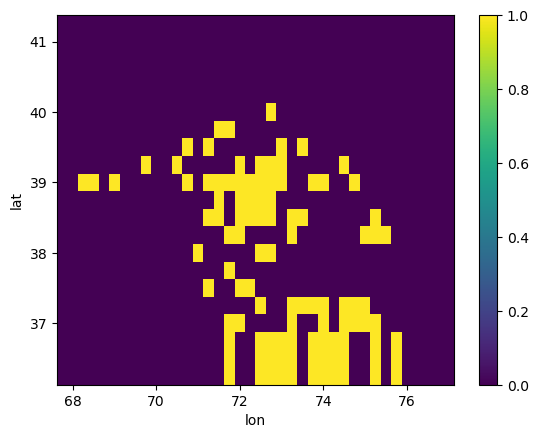

In [25]:
ice_resampled.plot()

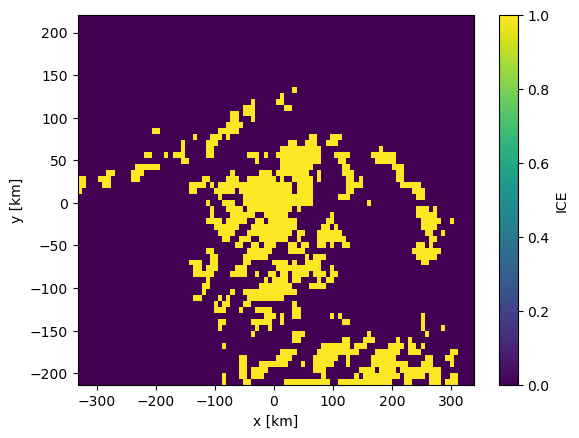

In [24]:
ICE_mask.plot()

In [27]:
FLH = FLH.mean(dim=['lat','lon'], skipna=True)

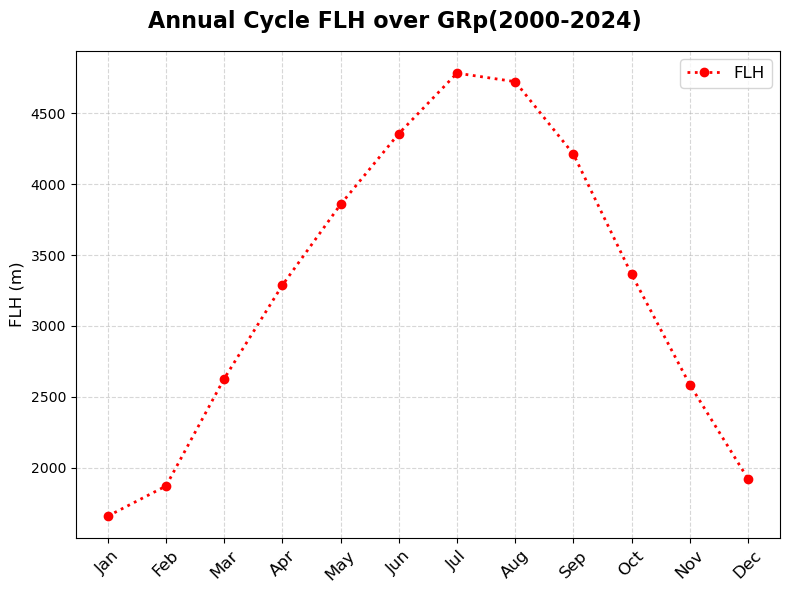

In [28]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = 'mm / month'

fig, ax = plt.subplots(figsize=(8,6))

da_flh = FLH

ax.plot(
        da_flh['month'], da_flh.values,
        marker='o', linestyle=':',
        color='red',
        label=f'FLH',
        linewidth=2
    )

# --- axes
ax.set_xticks(range(1,13))
ax.set_xticklabels(months, rotation=45, fontsize=12)

ax.set_ylabel(f'FLH (m)', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)

# --- legend
ax.legend(fontsize=12)

fig.suptitle(f'Annual Cycle FLH over {dom}({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout()
plt.show()